In [1]:

import numpy as np
from scipy.linalg import solve
import matplotlib.pyplot as plt

In [2]:
# ----------------------------------------------------------------
# BLOC 1 : PARAMETRES  (modifie alpha et N pour tester)
# ----------------------------------------------------------------
N     = 99       # nombre de points intérieurs
alpha = 1.0      # paramètre de régularisation (> 0)
h     = 1.0 / (N + 1)          # pas de discrétisation
x     = np.linspace(h, 1-h, N) # points x_1, x_2, ..., x_N
 
print(f"Paramètres : N={N}, alpha={alpha}, h={h:.4f}")

Paramètres : N=99, alpha=1.0, h=0.0100


In [3]:
# ----------------------------------------------------------------
# BLOC 2 : DONNEES f ET z_d
# Modifie ces deux lignes si le prof donne des fonctions précises
# ----------------------------------------------------------------
f   = np.sin(np.pi * x)   # second membre de l'EDP d'état
z_d = np.zeros(N)          # état désiré (cible)

In [4]:
# ----------------------------------------------------------------
# BLOC 3 : MATRICE TRIDIAGONALE A
# Discrétisation de l'opérateur -d²/dx²
# A = (1/h²) * tridiag(-1, 2, -1)
# ----------------------------------------------------------------
A = (1.0/h**2) * (
      np.diag(2.0  * np.ones(N))       # diagonale centrale : 2/h²
    + np.diag(-1.0 * np.ones(N-1), 1)  # sur-diagonale : -1/h²
    + np.diag(-1.0 * np.ones(N-1),-1)  # sous-diagonale : -1/h²
)

In [5]:
# ----------------------------------------------------------------
# BLOC 4 : CAS 1 — U_ad = L²(Omega), pas de contrainte
#
# Système :   A*Y + (1/alpha)*P = F       ... (E)
#             A*P - Y           = -Z      ... (F)
#
# Elimination : de (F) => Y = A*P + Z
# Substitution dans (E) => (A² + (1/alpha)*I)*P = F - A*Z
# ----------------------------------------------------------------
print("\n--- CAS 1 : sans contrainte ---")
 
second_membre = f - A @ z_d                          # F - A*Z
Matrice_cas1  = A @ A + (1.0/alpha) * np.eye(N)     # A² + (1/alpha)*I
 
P_cas1 = solve(Matrice_cas1, second_membre)          # résolution en P
Y_cas1 = A @ P_cas1 + z_d                           # Y = A*P + Z
U_cas1 = -(1.0/alpha) * P_cas1                      # u* = -(1/alpha)*p
 
print(f"  y* : min={Y_cas1.min():.4f}  max={Y_cas1.max():.4f}")
print(f"  p* : min={P_cas1.min():.4f}  max={P_cas1.max():.4f}")
print(f"  u* : min={U_cas1.min():.4f}  max={U_cas1.max():.4f}")
 


--- CAS 1 : sans contrainte ---
  y* : min=0.0032  max=0.1003
  p* : min=0.0003  max=0.0102
  u* : min=-0.0102  max=-0.0003


In [6]:
# ----------------------------------------------------------------
# BLOC 5 : CAS 2 — U_ad = {u >= 0}, contrainte u positif
#
# u*(x) = -(1/alpha)*min(0, p(x))
#
# Méthode : itérations de point fixe
#   1. Fixer P  =>  calculer u = -(1/alpha)*min(0,P)
#   2. Résoudre A*Y = f + u  (EDP état)
#   3. Résoudre A*P = Y - z_d  (EDP adjointe)
#   4. Répéter jusqu'à convergence
# ----------------------------------------------------------------
print("\n--- CAS 2 : avec contrainte u >= 0 ---")
 
P_cas2 = P_cas1.copy()   # initialisation depuis le cas 1
Y_cas2 = Y_cas1.copy()
 
for iteration in range(2000):
    P_avant = P_cas2.copy()
 
    # u*(x) = -(1/alpha)*min(0, p(x))
    # Si p >= 0 : u* = 0
    # Si p <  0 : u* = -p/alpha > 0
    U_iter = -(1.0/alpha) * np.minimum(0.0, P_cas2)
 
    # Résoudre EDP état :    -y'' = f + u  =>  A*Y = f + u
    Y_cas2 = solve(A, f + U_iter)
 
    # Résoudre EDP adjointe : -p'' = y-z_d =>  A*P = y - z_d
    P_cas2 = solve(A, Y_cas2 - z_d)
 
    # Critère de convergence
    erreur = np.linalg.norm(P_cas2 - P_avant)
    if erreur < 1e-10:
        print(f"  Convergence en {iteration+1} itérations (erreur={erreur:.2e})")
        break
 
U_cas2 = -(1.0/alpha) * np.minimum(0.0, P_cas2)
 
print(f"  y* : min={Y_cas2.min():.4f}  max={Y_cas2.max():.4f}")
print(f"  p* : min={P_cas2.min():.4f}  max={P_cas2.max():.4f}")
print(f"  u* : min={U_cas2.min():.4f}  max={U_cas2.max():.4f}")
print(f"  Vérification u* >= 0 partout : {np.all(U_cas2 >= -1e-12)}")
 


--- CAS 2 : avec contrainte u >= 0 ---
  Convergence en 2 itérations (erreur=0.00e+00)
  y* : min=0.0032  max=0.1013
  p* : min=0.0003  max=0.0103
  u* : min=-0.0000  max=-0.0000
  Vérification u* >= 0 partout : True


In [7]:
# ----------------------------------------------------------------
# BLOC 6 : VALEURS DU COUT J(u*)
# J(u) = int(y-z_d)² dx + alpha*int(u²) dx
# Approximation : somme de Riemann avec pas h
# ----------------------------------------------------------------
J1 = h * (np.sum((Y_cas1 - z_d)**2) + alpha * np.sum(U_cas1**2))
J2 = h * (np.sum((Y_cas2 - z_d)**2) + alpha * np.sum(U_cas2**2))
 
print(f"\n--- Valeurs du coût ---")
print(f"  J(u*) cas 1 = {J1:.6f}")
print(f"  J(u*) cas 2 = {J2:.6f}")
print(f"  J_cas2 >= J_cas1 (normal car contrainte) : {J2 >= J1 - 1e-10}")


--- Valeurs du coût ---
  J(u*) cas 1 = 0.005082
  J(u*) cas 2 = 0.005134
  J_cas2 >= J_cas1 (normal car contrainte) : True


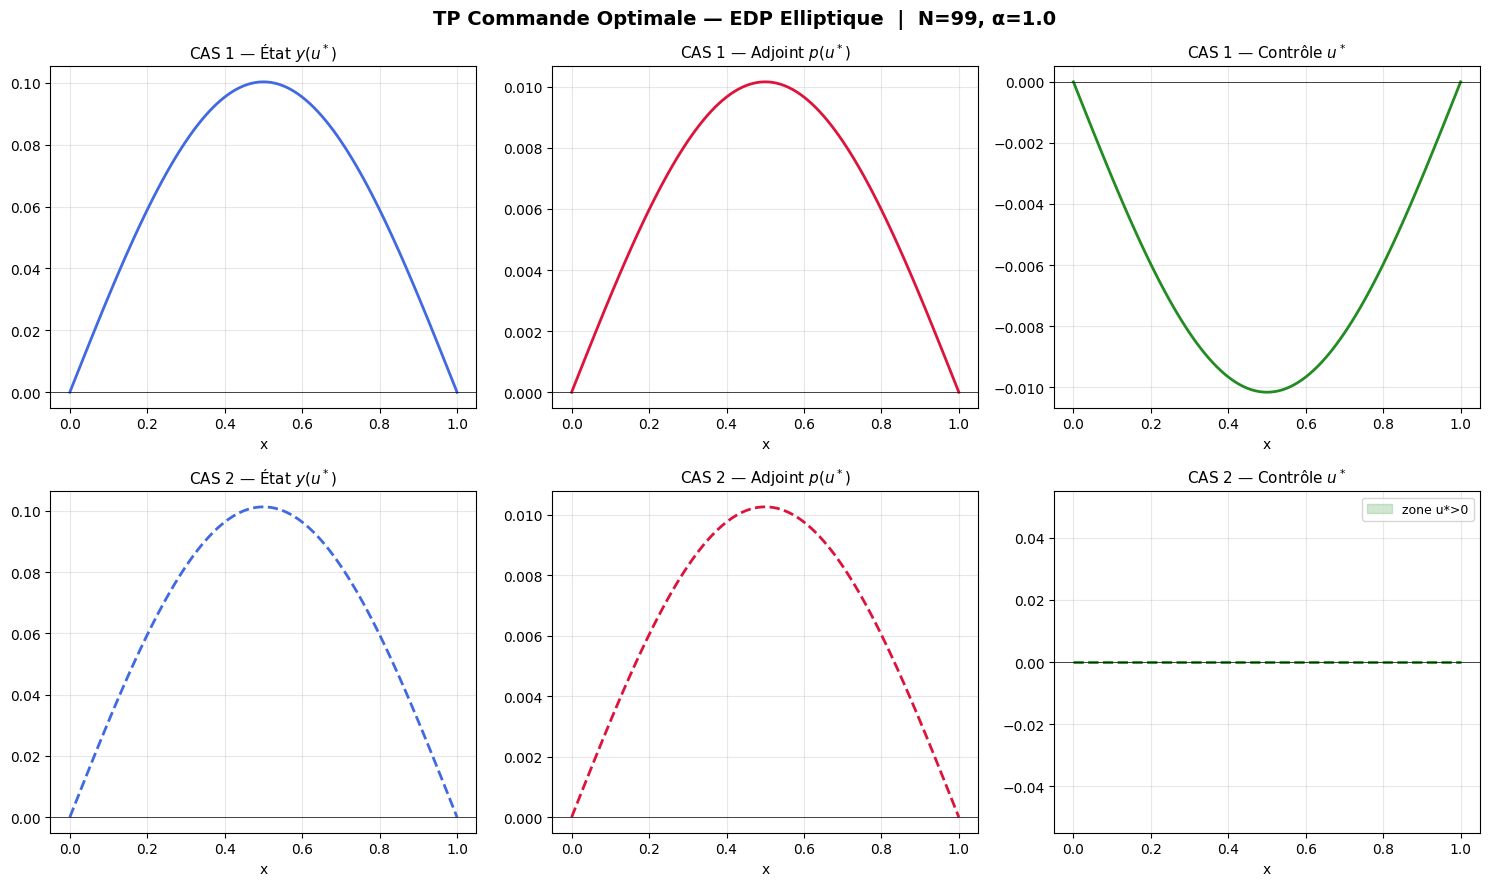


Graphique sauvegardé : tp_resultats.png


In [8]:
# ----------------------------------------------------------------
# BLOC 7 : GRAPHIQUES
# ----------------------------------------------------------------
 
# Ajouter les valeurs aux bords (= 0) pour un tracé propre
x_plot = np.concatenate([[0.0], x, [1.0]])
 
def ajouter_bords(v):
    """Ajoute 0 au début et à la fin du vecteur v"""
    return np.concatenate([[0.0], v, [0.0]])
 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    f"TP Commande Optimale — EDP Elliptique  |  N={N}, α={alpha}",
    fontsize=14, fontweight='bold'
)
 
# Données à tracer
donnees = {
    "CAS 1" : [Y_cas1, P_cas1, U_cas1],
    "CAS 2" : [Y_cas2, P_cas2, U_cas2],
}
titres   = ["État $y(u^*)$", "Adjoint $p(u^*)$", "Contrôle $u^*$"]
couleurs = ['royalblue', 'crimson', 'forestgreen']
lignes   = ['-', '--']
 
for i, (label, [Y, P, U]) in enumerate(donnees.items()):
    for j, (data, titre, couleur) in enumerate(zip([Y,P,U], titres, couleurs)):
        ax = axes[i, j]
        ax.plot(x_plot, ajouter_bords(data),
                color=couleur, linewidth=2, linestyle=lignes[i])
        ax.set_title(f"{label} — {titre}", fontsize=11)
        ax.set_xlabel("x")
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='black', linewidth=0.5)
 
        # Pour u* cas 2 : colorier la zone positive
        if j == 2 and i == 1:
            ax.fill_between(x_plot, 0, ajouter_bords(data),
                            where=ajouter_bords(data) > 0,
                            alpha=0.2, color='forestgreen',
                            label='zone u*>0')
            ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("tp_resultats.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphique sauvegardé : tp_resultats.png")